<a href="https://colab.research.google.com/github/gamal-zayed/Quantized-Low-Rank-Adaptation-Parameter-Efficient-Fine-Tuning/blob/main/QLoRA_Layer_Targeting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q trl peft bitsandbytes evaluate accelerate rouge_score bert_score matplotlib seaborn

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 863.2/863.2 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 13.8 MB/s eta 0:00:00


CELL A: SETUP + SHARED TRAINING FUNCTION
-

In [ ]:
# %% ==================== CELL A: SETUP + SHARED TRAINING FUNCTION ====================
# Works on BOTH Colab and Kaggle without edits -- auto-detects environment.
# Run this cell first, once, in either environment.

# !pip install -q trl peft bitsandbytes evaluate accelerate rouge_score bert_score
# (Kaggle: make sure "Internet" is toggled ON in notebook settings, and
#  Accelerator is set to GPU T4 x2 or P100, or this pip install / model
#  download will fail.)

import os, gc, json, time, shutil, torch
import pandas as pd
import numpy as np
from collections import Counter
from transformers import (
    AutoConfig, AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, PeftModel
from trl import SFTTrainer, SFTConfig
from datasets import load_dataset
import evaluate
from tqdm import tqdm

# ---- environment detection: Colab uses Drive, Kaggle uses /kaggle/working ----
try:
    from google.colab import drive
    drive.mount('/content/drive')
    ROOT = "/content/drive/MyDrive/exp_4_4_layer_targeting"
    ON_KAGGLE = False
    print("Detected Colab -- using Google Drive for persistence.")
except ImportError:
    ROOT = "/kaggle/working/exp_4_4_layer_targeting"
    ON_KAGGLE = True
    print("Detected Kaggle -- using /kaggle/working for persistence.")
    print("Reminder: commit ('Save Version') after each strategy finishes so")
    print("progress survives session boundaries -- /kaggle/working does NOT")
    print("persist across separate sessions unless you commit.")
os.makedirs(ROOT, exist_ok=True)

# ---- KAGGLE ONLY: if you added a previous committed version of this notebook
# as an input (to resume across sessions), copy its saved adapters back into
# the working directory before training, so the skip-if-completed logic below
# can see them. Safe no-op on Colab / if no such input exists.
if ON_KAGGLE:
    prior_input_root = "/kaggle/input"
    if os.path.isdir(prior_input_root):
        for entry in os.listdir(prior_input_root):
            candidate = os.path.join(prior_input_root, entry, "exp_4_4_layer_targeting")
            if os.path.isdir(candidate):
                print(f"Found prior output at {candidate} -- copying into {ROOT}")
                shutil.copytree(candidate, ROOT, dirs_exist_ok=True)

MODEL_ID = "microsoft/Phi-3-mini-4k-instruct"
SEED = 42

# ---- TEST_MODE: flip to True for a fast end-to-end smoke test (tiny
# n_train/epochs) to confirm every strategy cell below runs with ZERO
# syntax/logic errors before spending real Kaggle GPU hours. Run this in
# Colab first, confirm all 4 strategy cells + eval + chart complete cleanly,
# THEN set False and run for real on Kaggle. This is exactly the workflow
# you asked for.
TEST_MODE = False #True

if TEST_MODE:
    N_TRAIN = 20
    EPOCHS = 1
    print("TEST_MODE is ON -- using N_TRAIN=20, EPOCHS=1 for a fast smoke test.")
    print("Set TEST_MODE=False and rerun this cell before your real Kaggle run.")
else:
    N_TRAIN = 5000
    # Recommended: 1 (see time-budget note). Only set to 3 if you've confirmed
    # you have quota/session-time for it -- ~4.3h/strategy at n_train=5000,
    # epochs=3, vs ~85min/strategy at epochs=1.
    EPOCHS = 1

RANK = 8   # fixed per the brief's Experiment 4 instructions

# ---- fused-module parameter formula (verified against print_trainable_parameters
# in your earlier MLP-only run: predicted matched actual exactly) ----
PER_LAYER_COEF = {"qkv_proj": 7680, "o_proj": 6144, "gate_up_proj": 19456, "down_proj": 11264}
NUM_LAYERS = 32
def predicted_trainable_params(target_modules, r):
    return sum(PER_LAYER_COEF[m] for m in target_modules) * NUM_LAYERS * r

# ---- the four strategies, mapped onto Phi-3-mini's ACTUAL fused module names.
# Rationale: Phi-3 fuses q+k+v into one qkv_proj matrix and gate+up into one
# gate_up_proj matrix, so the brief's separate q_proj/k_proj/v_proj and
# gate_proj/up_proj names don't exist as distinct modules on this checkpoint.
# This is the closest faithful mapping onto the real architecture; note it
# explicitly in your report exactly as you did for MLP-only.
STRATEGIES = {
    "attention_only": ["qkv_proj"],
    "full_attention":  ["qkv_proj", "o_proj"],
    "attention_mlp":   ["qkv_proj", "o_proj", "gate_up_proj", "down_proj"],
    "mlp_only":        ["gate_up_proj", "down_proj"],
}

for name, mods in STRATEGIES.items():
    p = predicted_trainable_params(mods, RANK)
    print(f"{name:16s} target_modules={mods}  predicted_params={p:,}")

def audit_dtypes(model, label=""):
    all_dtypes = Counter(p.dtype for p in model.parameters())
    trainable_dtypes = Counter(p.dtype for p in model.parameters() if p.requires_grad)
    print(f"--- dtype audit {label} --- all: {dict(all_dtypes)} trainable: {dict(trainable_dtypes)}")
    return not any(p.requires_grad and p.dtype == torch.bfloat16 for p in model.parameters())

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=False)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

raw_dataset = load_dataset("keivalya/MedQuad-MedicalQnADataset", split="train")

def make_splits(seed, n_train):
    # Fixed val = LAST 500 shuffled samples (never overlaps train front-slice,
    # unlike a hardcoded range(5000,5500) which would leak for n_train>5000).
    shuffled = raw_dataset.shuffle(seed=seed)
    n_total = len(shuffled)
    val_dataset = shuffled.select(range(n_total - 500, n_total))
    train_dataset = shuffled.select(range(n_train))
    return train_dataset, val_dataset

def formatting_prompts_func(examples):
    q_types = examples.get('qtype', [''] * len(examples[list(examples.keys())[0]]))
    questions = examples.get('Question', examples.get('question'))
    answers = examples.get('Answer', examples.get('answer'))
    texts = []
    for qt, q, a in zip(q_types, questions, answers):
        messages = [
            {"role": "system", "content": "You are a knowledgeable medical assistant. Answer the patient's question clearly and accurately."},
            {"role": "user", "content": f"Context: {qt}. Question: {q}"},
            {"role": "assistant", "content": a}
        ]
        texts.append(tokenizer.apply_chat_template(messages, tokenize=False))
    return {"text": texts}

QUALITATIVE_PROBES = [
    "What is the first-line treatment for hypertension in a diabetic patient?",
    "What are the symptoms of type 2 diabetes?",
    "What causes rheumatoid arthritis?",
    "How is pneumonia diagnosed?",
    "What is the recommended treatment for a urinary tract infection?",
]

def train_strategy(strategy_name, rank=RANK, seed=SEED, n_train=None, epochs=None):
    """Generalized version of your working train_one_config -- same fixes
    (fp16/bnb dtype, sdpa, packing=False, skip-if-completed, resume-from-
    checkpoint) but parameterized by strategy so each of the 4 cells below
    just calls this with a different name."""
    n_train = N_TRAIN if n_train is None else n_train
    epochs = EPOCHS if epochs is None else epochs
    target_modules = STRATEGIES[strategy_name]

    run_name = f"{strategy_name}_r{rank}_seed{seed}_n{n_train}_ep{epochs}"
    adapter_dir = os.path.join(ROOT, run_name)
    meta_path = os.path.join(adapter_dir, "meta.json")

    if os.path.exists(meta_path):
        print(f"SKIPPING {run_name} -- already completed, found on disk.")
        with open(meta_path) as f:
            return json.load(f)

    print(f"\n{'='*60}\nTRAINING: {strategy_name}  target_modules={target_modules}"
          f"  r={rank}  n_train={n_train}  epochs={epochs}\n{'='*60}")

    from accelerate.state import AcceleratorState, PartialState
    AcceleratorState._reset_state()
    PartialState._reset_state()

    train_dataset, val_dataset = make_splits(seed, n_train)
    train_dataset = train_dataset.map(formatting_prompts_func, batched=True)
    val_dataset = val_dataset.map(formatting_prompts_func, batched=True)

    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True, bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
    )
    config = AutoConfig.from_pretrained(MODEL_ID)
    config._attn_implementation = "sdpa"   # revert to "eager" if this throws
                                            # a rotary-embedding-related error

    base_model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID, config=config, quantization_config=bnb_config,
        device_map={"": 0}, trust_remote_code=False, torch_dtype=torch.float16,
    )
    base_model.config.use_cache = False
    base_model = prepare_model_for_kbit_training(base_model)

    peft_config = LoraConfig(
        r=rank, lora_alpha=rank * 2, target_modules=target_modules,
        lora_dropout=0.05, bias="none", task_type="CAUSAL_LM",
    )
    model = get_peft_model(base_model, peft_config)

    ok = audit_dtypes(model, label=f"({strategy_name}, r={rank})")
    if not ok:
        for p in model.parameters():
            if p.requires_grad and p.dtype == torch.bfloat16:
                p.data = p.data.to(torch.float16)

    trainable_actual = sum(p.numel() for p in model.parameters() if p.requires_grad)
    predicted = predicted_trainable_params(target_modules, rank)
    print(f"Predicted: {predicted:,} | Actual: {trainable_actual:,}")

    out_dir = f"{ROOT}/_checkpoints/{run_name}"   # persistent, not /content or ephemeral
    training_config = SFTConfig(
        output_dir=out_dir,
        dataset_text_field="text",
        max_length=384,
        packing=False,
        per_device_train_batch_size=8,
        gradient_accumulation_steps=1,   # if this OOMs: batch_size=4, accum=2
        learning_rate=2e-4,
        num_train_epochs=epochs,
        logging_steps=10,
        eval_strategy="epoch",
        save_strategy="steps",
        save_steps=50,
        fp16=False, bf16=False,
        optim="paged_adamw_8bit",
        seed=seed,
        report_to=[],
    )
    training_config._n_gpu = 1

    trainer = SFTTrainer(
        model=model, train_dataset=train_dataset, eval_dataset=val_dataset,
        processing_class=tokenizer, args=training_config,
    )

    resume = os.path.isdir(out_dir) and any(d.startswith("checkpoint-") for d in os.listdir(out_dir))
    if resume:
        print(f"Found existing checkpoint in {out_dir} -- resuming.")

    t0 = time.time()
    trainer.train(resume_from_checkpoint=resume)
    wall_time = time.time() - t0
    val_loss = trainer.evaluate()["eval_loss"]

    model.save_pretrained(adapter_dir)
    tokenizer.save_pretrained(adapter_dir)

    meta = {
        "strategy": strategy_name, "target_modules": target_modules,
        "rank": rank, "seed": seed, "n_train": n_train, "epochs": epochs,
        "trainable_params_predicted": predicted,
        "trainable_params_actual": trainable_actual,
        "wall_time_sec": wall_time, "val_loss": val_loss,
        "adapter_dir": adapter_dir,
    }
    with open(meta_path, "w") as f:
        json.dump(meta, f, indent=2)

    del trainer, model, base_model
    gc.collect(); torch.cuda.empty_cache()
    return meta

print("Cell A complete. ROOT =", ROOT, "| TEST_MODE =", TEST_MODE)

Mounted at /content/drive
Detected Colab -- using Google Drive for persistence.
attention_only   target_modules=['qkv_proj']  predicted_params=1,966,080
full_attention   target_modules=['qkv_proj', 'o_proj']  predicted_params=3,538,944
attention_mlp    target_modules=['qkv_proj', 'o_proj', 'gate_up_proj', 'down_proj']  predicted_params=11,403,264
mlp_only         target_modules=['gate_up_proj', 'down_proj']  predicted_params=7,864,320


config.json:   0%|          | 0.00/967 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/3.44k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.94M [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/599 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/233 [00:00<?, ?B/s]

medDataset_processed.csv:   0%|          | 0.00/22.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16407 [00:00<?, ? examples/s]

Cell A complete. ROOT = /content/drive/MyDrive/exp_4_4_layer_targeting | TEST_MODE = False


CELL B: STRATEGY 1 -- ATTENTION ONLY
-

In [ ]:
# %% ==================== CELL B: STRATEGY 1 -- ATTENTION ONLY ====================
# target_modules=["qkv_proj"]. Safe to re-run: skips if already completed.
meta_attention_only = train_strategy("attention_only")
print(meta_attention_only)

SKIPPING attention_only_r8_seed42_n5000_ep1 -- already completed, found on disk.
{'strategy': 'attention_only', 'target_modules': ['qkv_proj'], 'rank': 8, 'seed': 42, 'n_train': 5000, 'epochs': 1, 'trainable_params_predicted': 1966080, 'trainable_params_actual': 3145728, 'wall_time_sec': 2640.120114803314, 'val_loss': 0.8586424589157104, 'adapter_dir': '/content/drive/MyDrive/exp_4_4_layer_targeting/attention_only_r8_seed42_n5000_ep1'}


CELL C: STRATEGY 2 -- FULL ATTENTION
-

In [ ]:
# %% ==================== CELL C: STRATEGY 2 -- FULL ATTENTION ====================
# target_modules=["qkv_proj", "o_proj"]. Safe to re-run: skips if already completed.
meta_full_attention = train_strategy("full_attention")
print(meta_full_attention)

SKIPPING full_attention_r8_seed42_n5000_ep1 -- already completed, found on disk.
{'strategy': 'full_attention', 'target_modules': ['qkv_proj', 'o_proj'], 'rank': 8, 'seed': 42, 'n_train': 5000, 'epochs': 1, 'trainable_params_predicted': 3538944, 'trainable_params_actual': 4718592, 'wall_time_sec': 4517.028274536133, 'val_loss': 0.8540444374084473, 'adapter_dir': '/content/drive/MyDrive/exp_4_4_layer_targeting/full_attention_r8_seed42_n5000_ep1'}


CELL D: STRATEGY 3 -- ATTENTION + MLP
-

In [ ]:
# %% ==================== CELL D: STRATEGY 3 -- ATTENTION + MLP ====================
# target_modules=["qkv_proj", "o_proj", "gate_up_proj", "down_proj"] (all four
# fused modules = the brief's "all seven modules"). Safe to re-run.
meta_attention_mlp = train_strategy("attention_mlp")
print(meta_attention_mlp)

SKIPPING attention_mlp_r8_seed42_n5000_ep1 -- already completed, found on disk.
{'strategy': 'attention_mlp', 'target_modules': ['qkv_proj', 'o_proj', 'gate_up_proj', 'down_proj'], 'rank': 8, 'seed': 42, 'n_train': 5000, 'epochs': 1, 'trainable_params_predicted': 11403264, 'trainable_params_actual': 12582912, 'wall_time_sec': 5721.2061812877655, 'val_loss': 0.8159942030906677, 'adapter_dir': '/content/drive/MyDrive/exp_4_4_layer_targeting/attention_mlp_r8_seed42_n5000_ep1'}


CELL E: STRATEGY 4 -- MLP ONLY
-

In [ ]:
# %% ==================== CELL E: STRATEGY 4 -- MLP ONLY ====================
# target_modules=["gate_up_proj", "down_proj"] -- same as your already-validated
# exp_4_4_mlp_only run, just re-run here under the unified 4-strategy naming
# scheme so Cell F's eval loop picks it up alongside the other three. Safe to
# re-run: skips if already completed.
meta_mlp_only = train_strategy("mlp_only")
print(meta_mlp_only)

SKIPPING mlp_only_r8_seed42_n5000_ep1 -- already completed, found on disk.
{'strategy': 'mlp_only', 'target_modules': ['gate_up_proj', 'down_proj'], 'rank': 8, 'seed': 42, 'n_train': 5000, 'epochs': 1, 'trainable_params_predicted': 7864320, 'trainable_params_actual': 7864320, 'wall_time_sec': 4804.315469741821, 'val_loss': 0.8255468606948853, 'adapter_dir': '/content/drive/MyDrive/exp_4_4_layer_targeting/mlp_only_r8_seed42_n5000_ep1'}


CELL F: EVAL ALL 4 STRATEGIES (run after B-E finish)
-

In [ ]:
# %% ==================== CELL F: EVAL ALL 4 STRATEGIES (run after B-E finish) ====================
# Loads the base model once, evaluates all four saved strategy adapters found
# under ROOT with ROUGE-L, BERTScore, and the qualitative probe questions.

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True, bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16, bnb_4bit_use_double_quant=True,
)
config = AutoConfig.from_pretrained(MODEL_ID)
config._attn_implementation = "sdpa"

print("Loading base model once for all eval runs...")
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, config=config, quantization_config=bnb_config,
    device_map={"": 0}, trust_remote_code=False, torch_dtype=torch.float16,
)
base_model.config.use_cache = True

rouge = evaluate.load("rouge")

from transformers import AutoTokenizer as _AutoTokenizer
if not getattr(_AutoTokenizer, "_clamp_patched", False):
    _orig_from_pretrained = _AutoTokenizer.from_pretrained.__func__
    def _clamped_from_pretrained(cls, *args, **kwargs):
        tok = _orig_from_pretrained(cls, *args, **kwargs)
        if getattr(tok, "model_max_length", 0) > 100000:
            tok.model_max_length = 512
        return tok
    _AutoTokenizer.from_pretrained = classmethod(_clamped_from_pretrained)
    _AutoTokenizer._clamp_patched = True

bertscore = evaluate.load("bertscore")

def make_val_split(seed):
    shuffled = raw_dataset.shuffle(seed=seed)
    n_total = len(shuffled)
    return shuffled.select(range(n_total - 500, n_total))   # matches make_splits()

def evaluate_strategy_adapter(adapter_dir, n_eval=10):
    with open(os.path.join(adapter_dir, "meta.json")) as f:
        meta = json.load(f)

    print(f"\nEvaluating {adapter_dir}  (strategy={meta['strategy']})")
    model = PeftModel.from_pretrained(base_model, adapter_dir)
    model.eval()

    val_dataset = make_val_split(meta["seed"]).select(range(n_eval))
    references, predictions = [], []
    for sample in tqdm(val_dataset, desc="generating"):
        ref = sample.get('Answer', sample.get('answer', ''))
        references.append(ref)
        qt = sample.get('qtype', '')
        q = sample.get('Question', sample.get('question', ''))
        messages = [
            {"role": "system", "content": "You are a knowledgeable medical assistant. Answer the patient's question clearly and accurately."},
            {"role": "user", "content": f"Context: {qt}. Question: {q}"},
        ]
        prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = tokenizer(prompt, return_tensors="pt").to("cuda:0")
        with torch.no_grad():
            out = model.generate(**inputs, max_new_tokens=150, do_sample=False)
        decoded = tokenizer.decode(out[0][inputs.input_ids.shape[1]:], skip_special_tokens=True)
        predictions.append(decoded.strip())

    rouge_res = rouge.compute(predictions=predictions, references=references)
    bert_res = bertscore.compute(predictions=predictions, references=references,
                                  model_type="microsoft/deberta-xlarge-mnli")

    qualitative = []
    for q in QUALITATIVE_PROBES:
        messages = [
            {"role": "system", "content": "You are a knowledgeable medical assistant. Answer the patient's question clearly and accurately."},
            {"role": "user", "content": q},
        ]
        prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = tokenizer(prompt, return_tensors="pt").to("cuda:0")
        with torch.no_grad():
            out = model.generate(**inputs, max_new_tokens=200, do_sample=False)
        decoded = tokenizer.decode(out[0][inputs.input_ids.shape[1]:], skip_special_tokens=True)
        qualitative.append({"question": q, "answer": decoded.strip()})

    with open(os.path.join(adapter_dir, "qualitative.json"), "w") as f:
        json.dump(qualitative, f, indent=2)

    model = model.unload()

    meta["rougeL"] = rouge_res["rougeL"]
    meta["bertscore_f1"] = float(np.mean(bert_res["f1"]))
    return meta


adapter_dirs = sorted(
    os.path.join(ROOT, d) for d in os.listdir(ROOT)
    if os.path.isdir(os.path.join(ROOT, d)) and os.path.exists(os.path.join(ROOT, d, "meta.json"))
)
strategy_results = [evaluate_strategy_adapter(d) for d in adapter_dirs]

df_strategies = pd.DataFrame(strategy_results).sort_values("strategy")
df_strategies.to_csv(os.path.join(ROOT, "exp_4_4_layer_targeting_results.csv"), index=False)
print(df_strategies[["strategy", "target_modules", "trainable_params_actual",
                      "wall_time_sec", "val_loss", "rougeL", "bertscore_f1"]])

best_row = df_strategies.loc[df_strategies["bertscore_f1"].idxmax()]
print(f"\nBest strategy by BERTScore F1: {best_row['strategy']} "
      f"(target_modules={best_row['target_modules']}, bertscore_f1={best_row['bertscore_f1']:.4f})")
print("Use this strategy's target_modules as your 'best configuration from "
      "Experiments 3-4' input for Experiment 5.")

Loading base model once for all eval runs...


model.safetensors.index.json:   0%|          | 0.00/16.5k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


...


Evaluating /content/drive/MyDrive/exp_4_4_layer_targeting/mlp_only_r8_seed42_n20_ep1  (strategy=mlp_only)


generating: 100%|██████████| 10/10 [01:58<00:00, 11.87s/it]



Evaluating /content/drive/MyDrive/exp_4_4_layer_targeting/mlp_only_r8_seed42_n5000_ep1  (strategy=mlp_only)


generating: 100%|██████████| 10/10 [01:34<00:00,  9.43s/it]


         strategy                               target_modules  \
0   attention_mlp  [qkv_proj, o_proj, gate_up_proj, down_proj]   
1   attention_mlp  [qkv_proj, o_proj, gate_up_proj, down_proj]   
2  attention_only                                   [qkv_proj]   
3  attention_only                                   [qkv_proj]   
4  full_attention                           [qkv_proj, o_proj]   
5  full_attention                           [qkv_proj, o_proj]   
6        mlp_only                    [gate_up_proj, down_proj]   
7        mlp_only                    [gate_up_proj, down_proj]   

   trainable_params_actual  wall_time_sec  val_loss    rougeL  bertscore_f1  
0                 12582912     188.348466  1.626209  0.152982      0.561833  
1                 12582912    5721.206181  0.815994  0.401318      0.722038  
2                  3145728     135.262242  1.706693  0.150809      0.565659  
3                  3145728    2640.120115  0.858642  0.335467      0.700601  
4              

CELL G: EXPERIMENT 4 -- COMPARISON VISUALIZATIONS
-

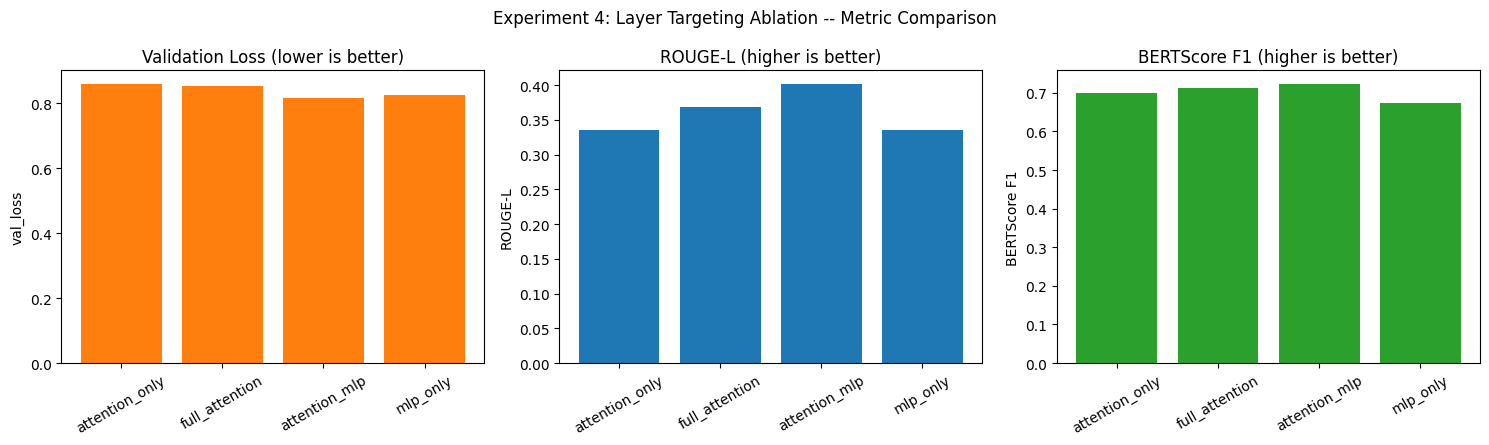

Saved /content/drive/MyDrive/exp_4_4_layer_targeting/exp_4_4_metric_comparison.png


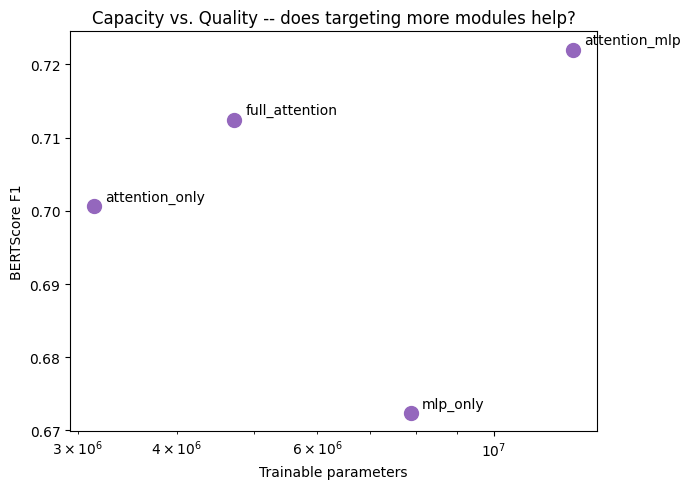

Saved /content/drive/MyDrive/exp_4_4_layer_targeting/exp_4_4_params_efficiency.png

=== Qualitative comparison for: "What is the first-line treatment for hypertension in a diabetic patient?" ===

--- attention_only ---
The first-line treatment for hypertension in a diabetic patient is an angiotensin-converting enzyme (ACE) inhibitor. ACE inhibitors are a class of medications that help relax blood vessels, lower blood pressure, and reduce the risk of heart attack and stroke. They are particularly effective in diabetic patients because they also help protect the kidneys from damage caused by high blood pressure an...

--- full_attention ---
The first-line treatment for hypertension in a diabetic patient is an angiotensin-converting enzyme (ACE) inhibitor. ACE inhibitors are a class of medications that help relax blood vessels, lower blood pressure, and reduce the risk of heart attack and stroke. They are particularly effective in diabetic patients because they also help protect the kidne

In [ ]:
# %% ==================== CELL G: EXPERIMENT 4 -- COMPARISON VISUALIZATIONS ====================
# Three views, chosen to directly support the brief's ask ("the value of this
# experiment is in the analysis"), not just a single plot:
#   1. Grouped bar chart -- val_loss / ROUGE-L / BERTScore per strategy
#   2. Params-efficiency scatter -- trainable params vs. quality (is the
#      extra capacity of "attention+MLP" actually buying anything?)
#   3. A markdown table of qualitative probe answers, one column per strategy,
#      for a single question -- the most readable "read the difference"
#      artifact for your report

import matplotlib.pyplot as plt

#df_plot = df_strategies.sort_values("strategy").reset_index(drop=True)
df_plot = df_strategies[df_strategies["n_train"] == 5000].copy()

strategy_order = ["attention_only", "full_attention", "attention_mlp", "mlp_only"]
df_plot["strategy"] = pd.Categorical(df_plot["strategy"], categories=strategy_order, ordered=True)
df_plot = df_plot.sort_values("strategy")

# ---- 1. Grouped bar chart: val_loss, ROUGE-L, BERTScore side by side ----
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].bar(df_plot["strategy"], df_plot["val_loss"], color="tab:orange")
axes[0].set_title("Validation Loss (lower is better)")
axes[0].set_ylabel("val_loss")
axes[0].tick_params(axis="x", rotation=30)

axes[1].bar(df_plot["strategy"], df_plot["rougeL"], color="tab:blue")
axes[1].set_title("ROUGE-L (higher is better)")
axes[1].set_ylabel("ROUGE-L")
axes[1].tick_params(axis="x", rotation=30)

axes[2].bar(df_plot["strategy"], df_plot["bertscore_f1"], color="tab:green")
axes[2].set_title("BERTScore F1 (higher is better)")
axes[2].set_ylabel("BERTScore F1")
axes[2].tick_params(axis="x", rotation=30)

plt.suptitle("Experiment 4: Layer Targeting Ablation -- Metric Comparison")
plt.tight_layout()
bar_path = os.path.join(ROOT, "exp_4_4_metric_comparison.png")
plt.savefig(bar_path, dpi=150)
plt.show()
print(f"Saved {bar_path}")

# ---- 2. Params-efficiency scatter: does more capacity actually help? ----
fig2, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df_plot["trainable_params_actual"], df_plot["bertscore_f1"], s=100, color="tab:purple")
for _, row in df_plot.iterrows():
    ax.annotate(row["strategy"],
                (row["trainable_params_actual"], row["bertscore_f1"]),
                textcoords="offset points", xytext=(8, 4))
ax.set_xlabel("Trainable parameters")
ax.set_ylabel("BERTScore F1")
ax.set_title("Capacity vs. Quality -- does targeting more modules help?")
ax.set_xscale("log")
plt.tight_layout()
scatter_path = os.path.join(ROOT, "exp_4_4_params_efficiency.png")
plt.savefig(scatter_path, dpi=150)
plt.show()
print(f"Saved {scatter_path}")

# ---- 3. Qualitative side-by-side table for one probe question ----
probe_to_compare = QUALITATIVE_PROBES[0]   # "first-line treatment for hypertension..."
print(f"\n=== Qualitative comparison for: \"{probe_to_compare}\" ===\n")
for _, row in df_plot.iterrows():
    qual_path = os.path.join(row["adapter_dir"], "qualitative.json")
    with open(qual_path) as f:
        qual = json.load(f)
    answer = next(q["answer"] for q in qual if q["question"] == probe_to_compare)
    print(f"--- {row['strategy']} ---")
    print(answer[:400] + ("..." if len(answer) > 400 else ""))
    print()

print("Quote 2-3 of these side by side in your report -- this is exactly the ")
print("'you ask a question and see the difference' evidence the brief wants.")